# Financial Status Prediction Using the 2024 FinAccess Household Survey

## Background

Financial inclusion plays a critical role in improving economic wellbeing and resilience among households. Understanding the factors associated with financial improvement or deterioration can help policymakers, financial institutions, and development organizations design targeted interventions.

## Objective

The objective of this project is to develop a machine learning model capable of predicting whether a Kenyan adult's financial situation has:

- Improved
- Stayed the same
- Worsened

using demographic, economic, behavioural, and financial inclusion indicators from the 2024 FinAccess Household Survey.

## Analytical Questions

This project seeks to answer the following questions:

1. What characteristics are associated with improved financial outcomes?
2. Which factors contribute most strongly to worsening financial conditions?
3. Which variables are most important for predicting financial status?
4. What recommendations can be derived from the findings?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

financialaccess = pd.read_excel('/kaggle/input/datasets/guyokana/financialaccess2024xlsx/finaccess2024_datasprint.xlsx')

print(financialaccess.shape, "\n")
print(financialaccess.info())

(20871, 28) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   county                 20871 non-null  object
 1   location_type          20871 non-null  object
 2   Sex                    20871 non-null  object
 3   Age                    20871 non-null  object
 4   household_size         20871 non-null  int64 
 5   education_level        20871 non-null  object
 6   marital_status         20871 non-null  object
 7   monthly_income         20871 non-null  int64 
 8   Savings_formal         20871 non-null  object
 9   Savings_informal       20871 non-null  object
 10  Loan_formal            20871 non-null  object
 11  Loan_informal          20871 non-null  object
 12  defaulted              20871 non-null  object
 13  formal_service_use     20871 non-null  object
 14  mobile_money_access    20871 non-null  object
 15  barri

The dataset contains 20.871 respondents and 28 variables, with every row representing one Kenyan adult surveyed in the FinAccess 2024 study. 

The variables cover several dimensions:

- Demographics
- Household characteristics
- Income
- Financial behaviour
- Financial inclusion
- Financial health indicators
- Financial outcomes

In [2]:
financialaccess.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
county,20871,47,Meru,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,20871,2,Rural,13549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,20871,2,Female,12326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20871,6,26-35,5361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,20871.0,NaN,NaN,NaN,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
education_level,20871,13,"""Secondary completed """,4113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,20871,6,Married/Living with partner,11432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,20871.0,NaN,NaN,NaN,9702.77428,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
Savings_formal,20871,2,Non-usage,11635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Savings_informal,20871,2,Non-usage,16031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Description

* The dataset contains 20,871 respondents and 28 variables (3 numeric, 25 categorical), with no missing values except `barriers_bank` (15,137 non-null, ~27.5% missing).

* Respondents span all 47 counties, are predominantly rural (13,549, ~65%) and female (12,326, ~59%), with the 26–35 age band most common (5,361). Average household size is 4.2 (median 4, range 1–20).

* Monthly income is highly skewed: median KES 5,000 vs. mean KES 9,703 (range 100–200,000), reflecting a small number of high earners.

* Financial behaviour is dominated by non-usage of formal and informal savings/loans (e.g., informal savings non-usage at 16,031, ~77%), despite high formal service use overall (18,224, ~87%). Mobile money access (17,868, ~86%) and ownership (16,888, ~81%) are both widespread.

* The target, `financial_status`, has three classes: Worsened (10,981, 52.6%), Stayed the same (26.9%), Improved (20.5%) — a moderately imbalanced target.

* `fl_score` (financial literacy) is mostly "Two correct" (8,580), and `prodsum1` (product count) averages 3.94 (range 0–22). Where `barriers_bank` is reported, "Affordability" dominates (10,223 of 15,137).

* Most respondents are married or living with a partner (11,432), and "Secondary completed" is the most common education level (4,113) among 13 categories.

* Loan usage mirrors the savings pattern, with non-usage dominant for both formal (12,340, ~59%) and informal (12,604, ~60%) loans, and most respondents report no default history (13,920, ~67%).

* Barriers to mobile money are mostly absent; "0" (no barrier) accounts for 16,409 of 20,871 responses across 10 categories.

* For the financial health indicators, `nfhi_11`, `nfhi_12`, and `nfhi_13` are all majority "Yes" (10,744, 12,887, and 13,151, respectively), while `experienced_shock` is majority "No" (11,785) and `not_difficult` is majority "No" (16,337) — the latter implying most respondents *do* report some difficulty.

Finally, the large majority of all respondents report no disability (19936)

## Data Understanding
###  Rural vs Urban
Approximately 65% of respondents reside in rural areas, indicating that the dataset predominantly reflects rural experiences. This distribution is important because financial inclusion, income-generating opportunities, and exposure to economic shocks may differ between rural and urban populations. Consequently, location type may be an important factor influencing financial outcomes.

### Income Distribution
The median monthly income is KES 5,000 while the mean income is approximately KES 9,700. This substantial gap indicates that income is unevenly distributed across respondents. 
While a small proportion of respondents earn relatively high incomes, the typical respondent earns considerably less, suggesting that many households may have limited financial capacity to absorb economic shocks or accumulate savings. Income is therefore expected to be an important factor influencing financial status outcomes.

### Financial Status 
The target variable, financial_status, represents respondents' self-reported assessment of whether their financial situation has improved, remained the same, or worsened.
Because the measure is self-reported, it captures perceived financial wellbeing rather than an objective measure such as income growth. Consequently, the model should be interpreted as predicting perceived financial change rather than absolute economic performance.

### Experienced Shock
The experienced_shock variable indicates whether a respondent encountered a significant adverse event.

Such shocks may include income loss, illness, business disruption, environmental events, or other unexpected hardships. Since shocks can reduce income and deplete savings, respondents reporting shocks may be more likely to experience worsening financial conditions.

### Financial Literacy
The fl_score variable measures financial literacy using four ordinal categories ranging from zero to three correct responses. Higher financial literacy may improve an individual's ability to manage finances, evaluate financial products, save effectively, and avoid excessive debt. Consequently, financial literacy may be positively associated with financial improvement.

### Emergency Fund Access
The accessto_13k_1month variable measures whether respondents could raise approximately KES 13,000 within one month if needed. This serves as an indicator of financial resilience and emergency preparedness. Individuals who can access emergency funds may be better positioned to cope with unexpected expenses without experiencing financial deterioration.





### Data Expectations

Based on the characteristics of the dataset and prior understanding of financial inclusion, the following relationships are expected:

- Lower income respondents may be more likely to report worsening financial conditions.
- Respondents experiencing shocks may be more likely to report financial deterioration.
- Financial literacy may be associated with improved outcomes.
- Access to emergency funds may improve financial resilience.
- Formal financial service usage may be associated with financial stability.
- Mobile money access may contribute to financial inclusion and resilience.

## Data Cleaning

In [3]:

#Remove special characters, whitespace and enforces type
financialaccess['education_level'] = (
    financialaccess['education_level'].astype(str).str.strip('"').str.strip().replace({'95.0': 'Unknown'})
)

#Clean Age
financialaccess['Age'] = (
    financialaccess['Age'].astype(str).str.strip().replace({'Above 55': '55+'})
)

#Clean Financial Status
financialaccess['financial_status'] = (
    financialaccess['financial_status'].str.strip().str.title()
)


#FL score mapping for easier readability and feature engineering if necessary
score_map = {
    'None correct': 0,
    'One correct': 1,
    'Two correct': 2,
    'All correct': 3
}

financialaccess['fl_score_num'] = financialaccess['fl_score'].map(score_map)

#Missing values
financialaccess['barriers_bank'] = financialaccess['barriers_bank'].fillna('No barrier')

print(financialaccess.head(10))

     county location_type     Sex    Age  household_size  \
0   Garissa         Urban  Female  26-35               5   
1   Garissa         Urban  Female    55+              11   
2     Busia         Urban  Female  26-35               2   
3    Kiambu         Urban    Male  18-25               1   
4  Murang'a         Urban  Female  18-25               1   
5    Kilifi         Rural  Female    55+               3   
6      Meru         Rural  Female  36-45               6   
7    Kilifi         Rural    Male  36-45               7   
8    Kisumu         Urban  Female  26-35               4   
9   Baringo         Urban    Male  26-35               1   

                                     education_level  \
0  Completed technical training after secondary s...   
1                                               None   
2                                  Primary completed   
3                                     Some secondary   
4     Some technical training after secondary school   
5  

- Standardized text formatting in categorical variables (e.g., education level and financial status).
- Renamed age categories for consistency.
- Mapped financial literacy scores to a numerical scale for potential modelling and analysis.
- Replaced missing values in `barriers_bank` with `"No barrier"` as specified in the competition brief.
- Verified data quality and consistency before proceeding to exploratory analysis.

## Data EDA
### Target Distribution


Text(0, 0.5, 'Number of Respondents')

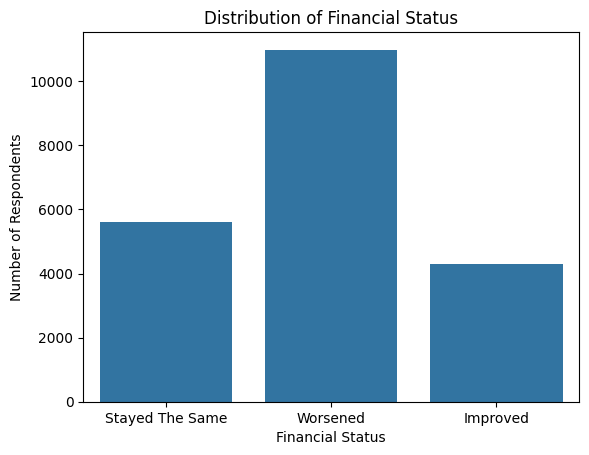

In [4]:
sns.countplot(
    data=financialaccess,
    x='financial_status',
)
plt.title('Distribution of Financial Status')
plt.xlabel('Financial Status')
plt.ylabel('Number of Respondents')

The target variable exhibits a clear class imbalance. More than half of respondents (52.6%) reported that their financial situation worsened. This imbalance creates a risk that a model may favour the majority class ("Worsened") at the expense of the minority classes. Consequently, weighted F1-score is more appropriate than accuracy because it evaluates performance across all classes while accounting for class frequencies.

### Monthly Income Distribution

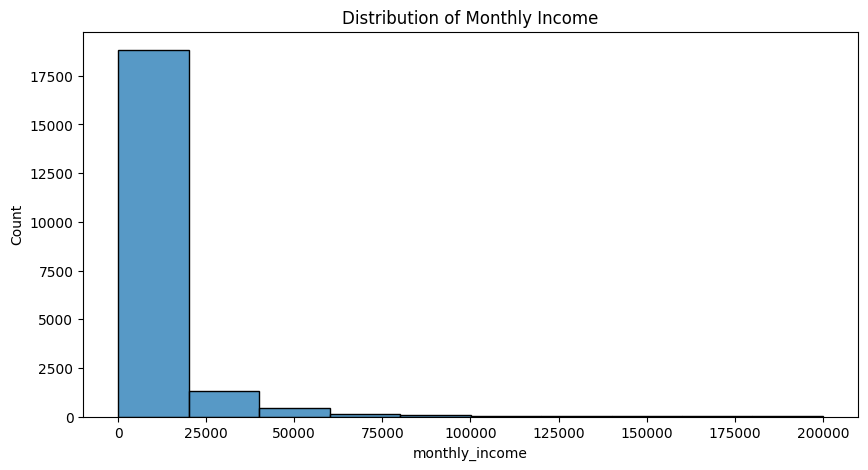

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    financialaccess['monthly_income'],
    bins = 10
)

plt.title("Distribution of Monthly Income")
plt.show()

The income distribution is strongly rigthly-skewed. The majority of respondents are concentrated in the lower income ranges, suggesting that many households operate within limited financial resources.
This concentration in low income brackets is consistent with limited capacity for savings, emergency preparedness, and risk absorption across most of the sample, supporting the expectation that income will be associated with financial status.

### Income vs Financial Status


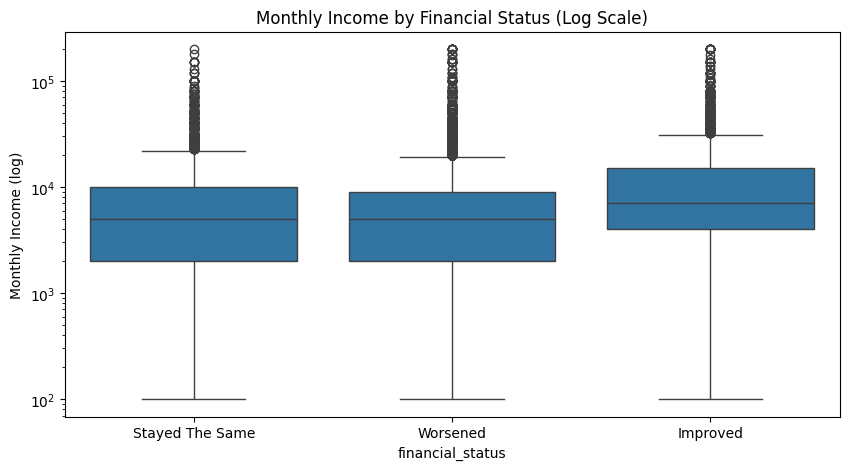

In [6]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=financialaccess,
    x='financial_status',
    y='monthly_income'
)

plt.yscale('log') 
plt.title("Monthly Income by Financial Status (Log Scale)")
plt.ylabel("Monthly Income (log)")
plt.show()

The original hypothesis that lower income predicts "Worsened" status is only partially supported. A more accurate reading is that higher income is associated with reporting improvement, but income level doesn't meaningfully distinguish between people whose situation stayed stable versus those who declined. This suggests income alone is a weak discriminator for the majority of the income distribution, and that other factors (shocks, access to emergency funds, financial product usage) likely do more work in separating "Worsened" from "Stayed the same," while income may matter more specifically for moving up into "Improved".

This suggests that higher income acts as a protective factor against financial deterioration.

### Experienced Shock vs Financial Status

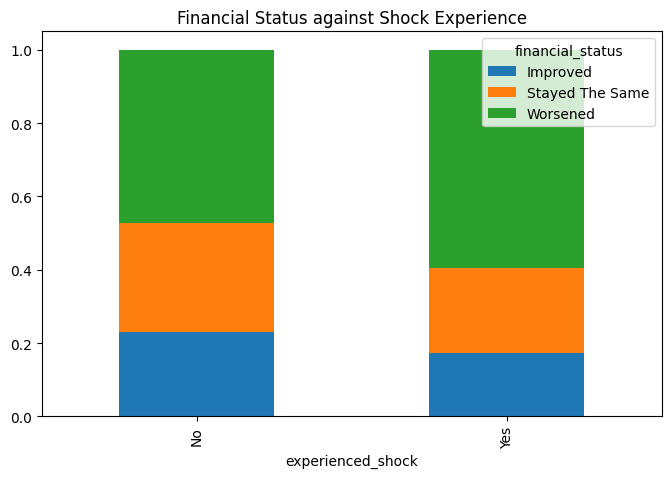

In [7]:
shock_table = pd.crosstab(
    financialaccess['experienced_shock'],
    financialaccess['financial_status'],
    normalize='index'
)

shock_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Financial Status against Shock Experience")
plt.show()

A substantially larger proportion (difference of about 12%) of "Worsened" responses among individuals who experienced shocks provides evidence that shocks contribute directly to financial vulnerability. This pattern holds across the other two categories too: "Improved" drops slightly (from ~23% to ~18%) and "Stayed the same" drops more noticeably (from ~30% to ~23%) when shock was experienced.

Shock is therefore a more discriminating variable than monthly income.

### Access to Emergency Funds vs Financial Status

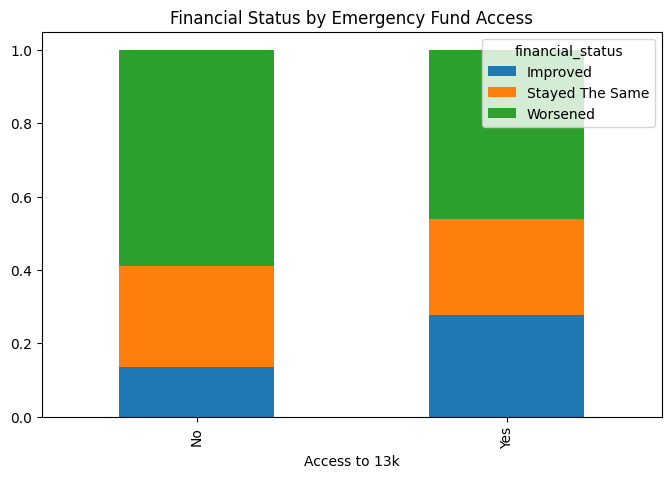

In [8]:
funds_table = pd.crosstab(
    financialaccess['accessto_13k_1month'],
    financialaccess['financial_status'],
    normalize='index'
)

funds_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Financial Status by Emergency Fund Access")
plt.xlabel("Access to 13k")
plt.show()

Majority of respondents with no access to KES 13,000 within one month reported "Worsened" financial status. This demonstrates that households/individuals unable to raise emergency funds are often financially fragile and may struggle to cope with unexpected expenses/financial shock. This variable captures preparedness rather than current income, making it a stronger measure of financial strength.

Coupled with Experienced Shock against Financial Status, it paints the picture that financial resilience determines financial status.

### Financial Literacy Score vs Financial Status

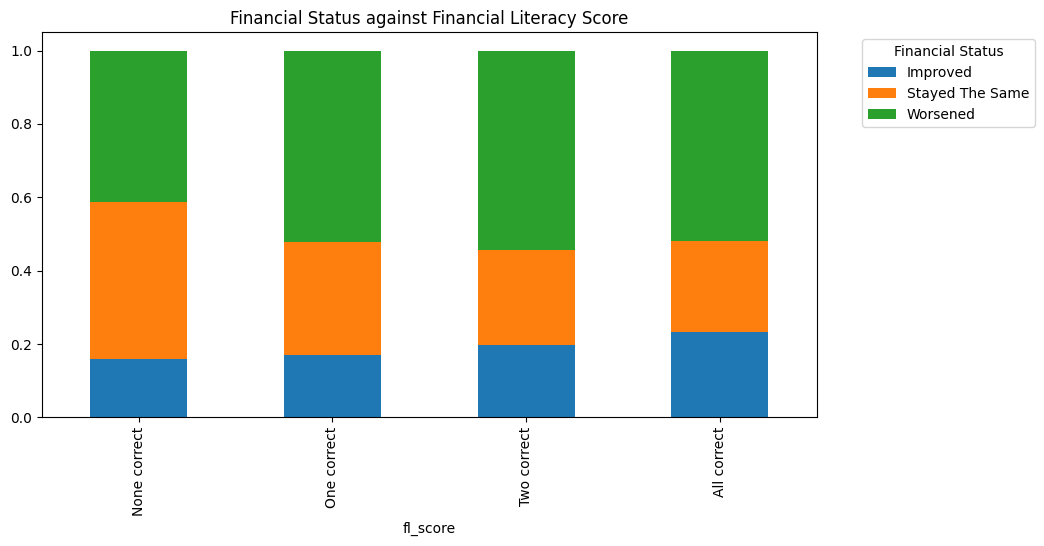

In [9]:
literacy_table = pd.crosstab(
    financialaccess['fl_score'],
    financialaccess['financial_status'],
    normalize='index'
)

order = ['None correct', 'One correct', 'Two correct', 'All correct']
literacy_table = literacy_table.reindex(order)

literacy_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Financial Status against Financial Literacy Score")
plt.legend(title="Financial Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The relationship between financial literacy and financial status appears weaker and less consistent than initially expected.
While respondents who answered all financial literacy questions correctly show a slightly higher proportion of improved financial outcomes, the relation does not change across those who answered one correct and two correct. In particular, respondents with no correct answers exhibit a lower share of worsening financial conditions and a higher share of stable outcomes than higher-scoring groups.

These findings suggest that financial literacy alone may not be a strong predictor of financial wellbeing. Knowledge of financial concepts does not necessarily translate into behaviours that improve financial resilience.